In [4]:
import pandas as pd

# Load the cleaned Dashen reviews CSV
dashen_df = pd.read_csv("../data/processed/dashen_bank_cleaned_reviews.csv")

# Display basic info and first few rows
print("Shape:", dashen_df.shape)
print(dashen_df.columns)
dashen_df.head()


Shape: (314, 5)
Index(['review', 'rating', 'date', 'bank', 'source'], dtype='object')


,review,rating,date,bank,source
0,I like this mobile banking app very much. Over...,2,2025-06-07,Dashen Bank,Google Play
1,Massive upgrade from the Amole app.,5,2025-05-31,Dashen Bank,Google Play
2,very good for this app,5,2025-05-31,Dashen Bank,Google Play
3,top,5,2025-05-31,Dashen Bank,Google Play
4,this app better than Amole . but the biometric...,4,2025-05-31,Dashen Bank,Google Play


In [5]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary resources (only needed once)
nltk.download('punkt')
nltk.download('stopwords')

# Define stopwords
stop_words = set(stopwords.words('english'))

# Define a preprocessing function
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove digits and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(filtered_tokens)

# Apply preprocessing to a new column
dashen_df['cleaned_review'] = dashen_df['review'].astype(str).apply(preprocess_text)

# Preview
dashen_df[['review', 'cleaned_review']].head()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,cleaned_review
0,I like this mobile banking app very much. Over...,like mobile banking app much overall user inte...
1,Massive upgrade from the Amole app.,massive upgrade amole app
2,very good for this app,good app
3,top,top
4,this app better than Amole . but the biometric...,app better amole biometric new update doesnt work


In [7]:

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import string

# Combine stopwords from nltk and punctuation
stop_words = set(stopwords.words('english') + list(string.punctuation))

# Define a preprocessing function for TF-IDF
def preprocess_text(text):
    tokens = text.lower().split()
    tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
    return ' '.join(tokens)

# Apply preprocessing
dashen_df['clean_review'] = dashen_df['review'].astype(str).apply(preprocess_text)

# Run TF-IDF
vectorizer = TfidfVectorizer(max_features=30, ngram_range=(1, 2))
X = vectorizer.fit_transform(dashen_df['clean_review'])

# Extract top TF-IDF keywords
tfidf_keywords = vectorizer.get_feature_names_out()
print("Top TF-IDF Keywords:")
print(tfidf_keywords)


Top TF-IDF Keywords:
['always' 'amazing' 'app' 'application' 'bank' 'bank super' 'banking'
 'best' 'dashen' 'dashen bank' 'dashen super' 'digital' 'easy' 'fast'
 'features' 'good' 'keep' 'like' 'make' 'mobile' 'mobile banking' 'one'
 'one step' 'really' 'seamless' 'step' 'super' 'super app' 'use' 'user']


In [8]:
import spacy
from collections import Counter

# Load English spaCy model
nlp = spacy.load("en_core_web_sm")

# Function to extract noun chunks
def extract_noun_chunks(text):
    doc = nlp(text)
    return [chunk.text.lower() for chunk in doc.noun_chunks if len(chunk.text.split()) > 1]

# Apply to all reviews
dashen_df['noun_chunks'] = dashen_df['review'].astype(str).apply(extract_noun_chunks)

# Flatten and count most common noun chunks
all_chunks = [chunk for sublist in dashen_df['noun_chunks'] for chunk in sublist]
chunk_counts = Counter(all_chunks)
top_chunks = chunk_counts.most_common(20)

print("Top Noun Phrases (spaCy):")
for phrase, count in top_chunks:
    print(f"{phrase}: {count}")


Top Noun Phrases (spaCy):
the app: 27
dashen bank: 23
this app: 21
dashen super app: 12
dashen bank super app: 9
one place: 9
the dashen super app: 7
always one step: 6
a lot: 6
bill payments: 5
a game-changer: 5
amazing app: 4
the chat banking: 4
the application: 4
the dashen bank super app: 4
one step: 4
digital banking: 3
the best app: 3
nice app: 3
the go: 3


In [9]:
# Define themes and their keywords
themes = {
    "Login Issues": ["login", "sign in", "account access", "password"],
    "Transaction Problems": ["transfer", "transaction", "delay", "failed", "crash"],
    "App Usability": ["interface", "user friendly", "app design", "easy to use"],
    "Customer Support": ["support", "help", "contact"],
    "Positive Feedback": ["great", "good", "excellent", "love", "smooth", "helpful"]
}

# Function to assign themes to a review
def identify_themes(text):
    found_themes = []
    for theme, keywords in themes.items():
        for keyword in keywords:
            if keyword in text.lower():
                found_themes.append(theme)
                break  # avoid duplicate theme assignment
    return found_themes if found_themes else ["Other"]

# Apply function
dashen_df['themes'] = dashen_df['review'].astype(str).apply(identify_themes)

# Show sample
dashen_df[['review', 'themes']].head(10)


,review,themes
0,I like this mobile banking app very much. Over...,[App Usability]
1,Massive upgrade from the Amole app.,[Other]
2,very good for this app,[Positive Feedback]
3,top,[Other]
4,this app better than Amole . but the biometric...,[Other]
5,wow to it saff and this app,[Other]
6,it too slow,[Other]
7,real life changer,[Other]
8,useless app ever loading take long,[Other]
9,Game changer app! Dashen Bank Super App is fas...,"[Login Issues, App Usability, Positive Feedback]"


C:\Users\PC\AppData\Local\Temp\ipykernel_5108\685434337.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=theme_df, x='count', y='theme', palette='viridis')


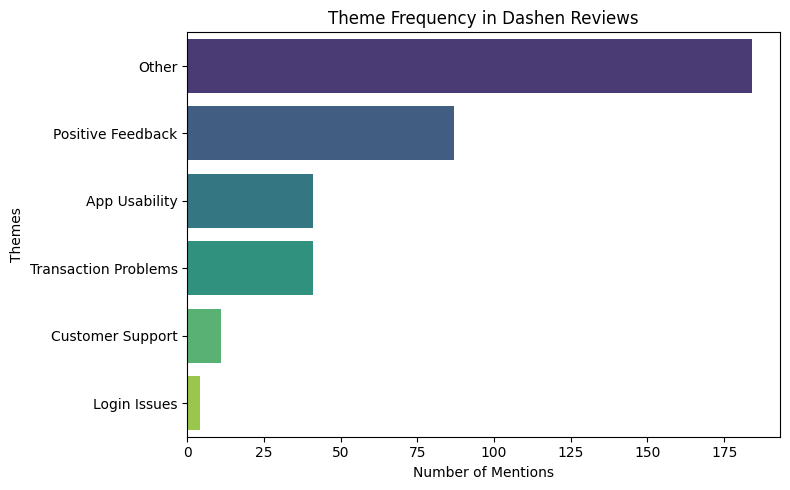

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Flatten all themes into a single list
all_themes = [theme for sublist in dashen_df['themes'] for theme in sublist]
theme_counts = Counter(all_themes)

# Convert to DataFrame
theme_df = pd.DataFrame.from_dict(theme_counts, orient='index', columns=['count']).reset_index()
theme_df.columns = ['theme', 'count']
theme_df = theme_df.sort_values(by='count', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=theme_df, x='count', y='theme', palette='viridis')
plt.title("Theme Frequency in Dashen Reviews")
plt.xlabel("Number of Mentions")
plt.ylabel("Themes")
plt.tight_layout()
plt.show()


In [11]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

# Initialize VADER
sid = SentimentIntensityAnalyzer()

# Analyze sentiment for each review
sentiment_labels = []
sentiment_scores = []

for review in tqdm(dashen_df['review']):
    score = sid.polarity_scores(str(review))['compound']
    sentiment_scores.append(score)

    if score >= 0.05:
        sentiment_labels.append('positive')
    elif score <= -0.05:
        sentiment_labels.append('negative')
    else:
        sentiment_labels.append('neutral')

# Create sentiment_results DataFrame
sentiment_results = pd.DataFrame({
    'sentiment': sentiment_labels,
    'sentiment_score': sentiment_scores
})

# Attach it to dashen_df
dashen_df = dashen_df.reset_index(drop=True)
sentiment_results = sentiment_results.reset_index(drop=True)

dashen_df['sentiment'] = sentiment_results['sentiment']
dashen_df['sentiment_score'] = sentiment_results['sentiment_score']

print("✅ Sentiment scores added!")


  0%|          | 0/314 [00:00<?, ?it/s]

✅ Sentiment scores added!


In [12]:
print(dashen_df.columns)

Index(['review', 'rating', 'date', 'bank', 'source', 'cleaned_review',
       'clean_review', 'noun_chunks', 'themes', 'sentiment',
       'sentiment_score'],
      dtype='object')


In [13]:
# Select columns to save
final_df = dashen_df[['review', 'rating', 'date', 'sentiment', 'sentiment_score', 'themes']]

# Save to CSV
final_df.to_csv("dashen_sentiment_themes.csv", index=False)




In [14]:
print(dashen_df.columns)

Index(['review', 'rating', 'date', 'bank', 'source', 'cleaned_review',
       'clean_review', 'noun_chunks', 'themes', 'sentiment',
       'sentiment_score'],
      dtype='object')


In [15]:
# Ensure sentiment_results exists and matches cbe_df
dashen_df = dashen_df.reset_index(drop=True)
sentiment_results = sentiment_results.reset_index(drop=True)

# Add the sentiment and score columns to cbe_df
dashen_df['sentiment'] = sentiment_results['sentiment']
dashen_df['sentiment_score'] = sentiment_results['sentiment_score']


In [16]:
# Save processed CBE data with sentiment and themes
output_path = "processed_dashen_data_with_sentiment_reviews.csv"
dashen_df.to_csv(output_path, index=False)
print(f"✅ Data saved to {output_path}")



✅ Data saved to processed_dashen_data_with_sentiment_reviews.csv
